In [121]:
import json
import os

In [122]:
import torch
from pathlib import Path
from splice import _LocWrapper  # needed for unpickling the saved SPLICE model
from paths import load_paths

In [123]:
from external.splice.splice.model import SPLICE

In [124]:
import argparse, json
from models.model import build_model

In [125]:
import torch.nn.functional as F
import pandas as pd
from tqdm import tqdm

In [126]:
MODEL_NAME = "csp_fmow_open_clip_vit_l"   # keys: geoclip_geoyfcc, geoclip_geospatial_all, satclip_geospatial, satclip_geospatial_all, satclip_open_clip_vit_h_n500000
CONCEPTS_NAME = "geospatial_all"

model_path = load_paths()["models"][MODEL_NAME]["model_path"]
concepts_json = load_paths()["concept_sets"]["git-10m"][CONCEPTS_NAME]
device = "cuda:0"


In [127]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

In [128]:
device = "cuda:0" if torch.cuda.is_available() else "cpu"

ckpt = torch.load(model_path, map_location=device)
model_args = argparse.Namespace(**ckpt['args'])
model_args.precomputed_location_embeddings = False  # need SatCLIP for raw coord inference
model = build_model(
    text_encoder=model_args.text_encoder,
    location_encoder=model_args.location_encoder,
    text_projection=model_args.text_projection,
    location_projection=model_args.location_projection,
    shared_dim=model_args.shared_dim,
    text_finetune_mode=model_args.text_finetune_mode,
    loc_finetune_mode=model_args.loc_finetune_mode,
    text_proj_hidden_layers=model_args.text_proj_hidden_layers,
    text_proj_hidden_features=model_args.text_proj_hidden_features,
    loc_proj_hidden_layers=model_args.loc_proj_hidden_layers,
    loc_proj_hidden_features=model_args.loc_proj_hidden_features,
    text_nonlinearity=model_args.text_nonlinearity,
    loc_nonlinearity=model_args.loc_nonlinearity,
    precomputed_text_embeddings=False,
    precomputed_location_embeddings=False,
    device=device,
)
model.load_state_dict(ckpt['model'], strict=False)  # SatCLIP weights not in ckpt, just projection
model.eval()

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] CLIPTextModelWithProjection LOAD REPORT from: openai/clip-vit-large-patch14
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
vision_model.encoder.layers.{0...23}.self_attn.out_proj.weight | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.mlp.fc1.weight            | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.self_attn.k_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.layer_norm1.bias          | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.layer_norm2.weight        | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.layer_norm1.weight        | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.self_attn.v_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.self_attn.q_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.mlp.fc2.weight            | UNEXPECTED |  | 
vision_

Loading CSP from /home/libe2152/data/csp/model_dir/model_fmow/model_fmow_gridcell_0.0010_32_0.1000000_1_512_gelu_UNSUPER-contsoftmax_0.000050_1.000_1_0.100_TMP1.0000_1.0000_1.0000.pth.tar...


/home/libe2152/projects/explainable-earth-embeddings/external/csp/main/module.py:98: FutureWarning: `nn.init.xavier_uniform` is now deprecated in favor of `nn.init.xavier_uniform_`.
  nn.init.xavier_uniform(self.linear.weight)


TextLocationModel(
  (text_encoder): TextEncoder(
    (embed_project): EmbeddingProjection(
      (net): Sequential(
        (0): Linear(in_features=768, out_features=256, bias=True)
      )
    )
    (text_encoder): CLIPText(
      (m): CLIPTextModelWithProjection(
        (text_model): CLIPTextModel(
          (embeddings): CLIPTextEmbeddings(
            (token_embedding): Embedding(49408, 768)
            (position_embedding): Embedding(77, 768)
          )
          (encoder): CLIPEncoder(
            (layers): ModuleList(
              (0-11): 12 x CLIPEncoderLayer(
                (self_attn): CLIPAttention(
                  (k_proj): Linear(in_features=768, out_features=768, bias=True)
                  (v_proj): Linear(in_features=768, out_features=768, bias=True)
                  (q_proj): Linear(in_features=768, out_features=768, bias=True)
                  (out_proj): Linear(in_features=768, out_features=768, bias=True)
                )
                (layer_norm1): La

In [129]:
BATCH_SIZE=1024
PCA_DIM=None
L1_PENALTY=0.175
subset_size = 10000

In [130]:
df = pd.read_csv("~/data/dense_grid/dense_grid.csv")
df = df.sample(subset_size, random_state=0).reset_index(drop=True)
latlons = torch.tensor(df[["lat", "lon"]].values, dtype=torch.float32).to(device)

In [131]:
out_path = f"figures/splice_decomposition/{MODEL_NAME}_{CONCEPTS_NAME}_subset_{subset_size}.png"
report_out_path = f"figures/splice_decomposition/{MODEL_NAME}_{CONCEPTS_NAME}_reconstruction_metrics_subset_{subset_size}.txt"

out_path = Path(out_path)
out_path.parent.mkdir(parents=True, exist_ok=True)

In [132]:
with torch.no_grad():
    loc_embs = model.location_model_predict(latlons)

with open(concepts_json) as f:
    concepts = json.load(f)
prompted = ["An image of a {concept}".format(concept=c) for c in concepts]
with torch.no_grad():
    emb_concepts = torch.cat([
        model.text_model_predict(prompted[i:i + BATCH_SIZE])
        for i in range(0, len(prompted), BATCH_SIZE)
    ])

if PCA_DIM is not None:
    from sklearn.decomposition import PCA
    print("Running PCA reduction...")
    pca = PCA(n_components=PCA_DIM)
    all_embs = torch.cat([loc_embs, emb_concepts], dim=0).cpu().numpy()
    pca.fit(all_embs)
    loc_embs = torch.tensor(pca.transform(loc_embs.cpu().numpy()), dtype=torch.float32).to(device)
    emb_concepts = torch.tensor(pca.transform(emb_concepts.cpu().numpy()), dtype=torch.float32).to(device)

mean_emb = loc_embs.mean(0)
emb_concepts = F.normalize(emb_concepts - emb_concepts.mean(0), dim=1)

splice_model = SPLICE(mean_emb, emb_concepts,
                        clip=_LocWrapper(model.location_encoder).to(device),
                        solver='admm', device=device, return_weights=True, return_cosine=True,
                        l1_penalty=L1_PENALTY, text_mean=None)
if PCA_DIM is not None:
    splice_model.pca = pca  # carried along so eval can apply the same transform
else:
    splice_model.pca = None

model_id = MODEL_NAME
concept_id = CONCEPTS_NAME
out = Path("splice_results") / model_id / concept_id
out.mkdir(parents=True, exist_ok=True)
torch.save(splice_model, out / "splice_model.pt")
torch.save(concepts, out / "concepts.pt")

Using ADMM solver...
With rho value 5.0


In [133]:
splice_model.clip

_LocWrapper(
  (enc): LocationEncoder(
    (location_encoder): LocationEncoder(
      (spa_enc): GridCellSpatialRelationEncoder(
        (ffn): MultiLayerFeedForwardNN(
          (layers): ModuleList(
            (0): SingleFeedForwardNN(
              (dropout): Dropout(p=0.5, inplace=False)
              (act): GELU(approximate='none')
              (layernorm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
              (linear): Linear(in_features=128, out_features=512, bias=True)
            )
            (1): SingleFeedForwardNN(
              (dropout): Dropout(p=0.5, inplace=False)
              (act): GELU(approximate='none')
              (linear): Linear(in_features=512, out_features=256, bias=True)
            )
          )
        )
      )
      (class_emb): Linear(in_features=256, out_features=62, bias=False)
      (user_emb): Linear(in_features=256, out_features=1, bias=False)
    )
  )
)

In [134]:
batch_size = 256
all_orig, all_weights, all_recon = [], [], []

with torch.no_grad():
    for i in tqdm(range(0, len(latlons), batch_size)):
        raw = splice_model.clip.encode_image(latlons[i:i + batch_size])
        if splice_model.pca is not None:
            raw = torch.tensor(pca.transform(raw.cpu().numpy()), dtype=torch.float32).to(device)
        orig_b = F.normalize(raw, dim=1)
        weights_b = splice_model.decompose(F.normalize(orig_b - splice_model.image_mean, dim=1))
        recon_b = splice_model.recompose_image(weights_b)
        all_orig.append(orig_b)
        all_weights.append(weights_b)
        all_recon.append(recon_b)

orig    = torch.cat(all_orig)
weights = torch.cat(all_weights)
recon   = torch.cat(all_recon)

mse      = F.mse_loss(recon, orig).item()
cos_sim  = (recon * orig).sum(dim=1).mean().item()
ss_res   = ((orig - recon) ** 2).sum()
ss_tot   = ((orig - orig.mean(0)) ** 2).sum()
r2       = (1 - ss_res / ss_tot).item()
l0_mean  = (weights > 0).float().sum(dim=1).mean().item()

print(f"MSE:              {mse:.4f}")
print(f"R²:               {r2:.4f}")
print(f"Cosine similarity:{cos_sim:.4f}")
print(f"Mean active concepts (L0): {l0_mean:.1f} / {weights.shape[1]}")

100%|██████████| 40/40 [00:06<00:00,  6.14it/s]

MSE:              0.0044
R²:               -0.3931
Cosine similarity:0.4413
Mean active concepts (L0): 15.4 / 1020


In [135]:
report = {
    "mse": mse,
    "r2": r2,
    "cosine_similarity": cos_sim,
    "mean_active_concepts_l0": l0_mean,
    "num_concepts": int(weights.shape[1]),
    "num_samples": int(len(orig)),
}

with open(report_out_path, "w") as f:
    json.dump(report, f, indent=4)

print(json.dumps(report, indent=4))

{
    "mse": 0.00436500133946538,
    "r2": -0.39314043521881104,
    "cosine_similarity": 0.4412797689437866,
    "mean_active_concepts_l0": 15.438299179077148,
    "num_concepts": 1020,
    "num_samples": 10000
}


In [136]:
plt.rcParams.update({
    'font.size': 16,           # Base font size
    'axes.titlesize': 18,      # Subplot titles (Paris, Sahara, etc.)
    'axes.labelsize': 16,      # X and Y labels
    'xtick.labelsize': 14,     # Axis tick numbers
    'ytick.labelsize': 15,     # Concept labels (illumination, etc.)
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial']
})

In [ ]:
locations = {
    "Paris":        ((48.8584,   2.2945), "#3a86ff"),
    "Sahara":        ((22.2348,   7.9586), "#e76f51"),
    "Siberia":               ((61.5240, 105.3188), "#588157"),
    "Bali": ((-8.409518, 115.188919), "#9b5de5")
    # "Midwest US":         ((41.8780, -93.0977), "#e9c46a"),
}

In [138]:
top_k = 4

In [139]:
all_vals = []
for name, ((lat, lon), color) in locations.items():
    latlon = torch.tensor([[lat, lon]], dtype=torch.float32, device=device)
    raw = splice_model.clip.encode_image(latlon)
    if splice_model.pca is not None:
        raw = torch.tensor(pca.transform(raw.cpu().numpy()), dtype=torch.float32).to(device)
    orig_b = F.normalize(raw, dim=1)
    weights_b = splice_model.decompose(F.normalize(orig_b - splice_model.image_mean, dim=1))
    recon_b = splice_model.recompose_image(weights_b)

    pairs = sorted(zip(concepts, weights_b[0].tolist()), key=lambda x: -x[1])
    pairs = [(c, v) for c, v in pairs if v > 0][:top_k]
    all_vals.extend([v for _, v in pairs])
xmax = max(all_vals) * 1.12

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

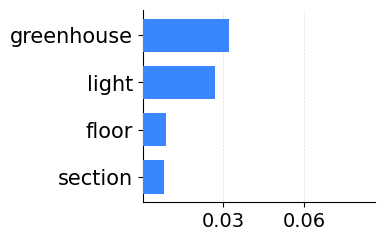

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

Saved: figures/splice_decomposition/csp_fmow_open_clip_vit_l_geospatial_all_subset_10000_paris.png


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

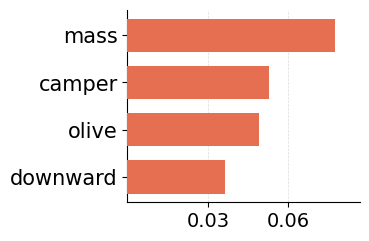

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

Saved: figures/splice_decomposition/csp_fmow_open_clip_vit_l_geospatial_all_subset_10000_sahara.png


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

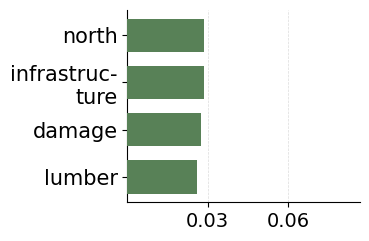

Saved: figures/splice_decomposition/csp_fmow_open_clip_vit_l_geospatial_all_subset_10000_siberia.png


In [140]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

def format_label(c, max_len=10):
    if ' ' in c:
        return c.replace(' ', '\n', 1)
    if len(c) > max_len:
        return c[:max_len] + '-\n' + c[max_len:]
    return c

plt.rcParams.update({'font.family': 'sans-serif', 'font.sans-serif': ['Arial']})

for name, ((lat, lon), color) in locations.items():
    latlon = torch.tensor([[lat, lon]], dtype=torch.float32, device=device)
    with torch.no_grad():
        raw = splice_model.clip.encode_image(latlon)
        if splice_model.pca is not None:
            raw = torch.tensor(pca.transform(raw.cpu().numpy()), dtype=torch.float32).to(device)
        orig_b = F.normalize(raw, dim=1)
        weights_b = splice_model.decompose(F.normalize(orig_b - splice_model.image_mean, dim=1))

    pairs = sorted(zip(concepts, weights_b[0].tolist()), key=lambda x: -x[1])
    pairs = [(c, v) for c, v in pairs if v > 0][:top_k]

    if not pairs:
        continue
    labels, vals = zip(*pairs)
    labels = [format_label(c) for c in labels]
    y = np.arange(len(vals))

    fig, ax = plt.subplots(figsize=(3.0, 2.5))

    ax.barh(y, vals, height=0.7, color=color, edgecolor="none", zorder=3)
    ax.set_yticks(y)
    ax.set_yticklabels(labels)
    ax.invert_yaxis()
    ax.set_xlim(0, xmax)

    ax.xaxis.set_major_locator(mticker.MaxNLocator(3, prune="both"))
    ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))

    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["left", "bottom"]].set_linewidth(0.8)
    ax.grid(axis="x", linewidth=0.5, linestyle="--", color="#cccccc", alpha=0.7, zorder=0)

    loc_filename = out_path.with_name(out_path.stem + f"_{name.lower().replace(' ', '_')}.png")
    plt.savefig(loc_filename, bbox_inches="tight", dpi=300)
    plt.show()
    print(f"Saved: {loc_filename}")